# Category volume planner — template for your own data

A per-category volume model with feature selection, validated hyperparameters, a
baseline forecast and scenario planning. Point it at your DataFrame and run.

**There is no pooled model.** Every category gets its own feature set, its own
validated hyperparameters, its own coefficients and its own driver forecasts. No
category sees another's data or borrows its coefficients. If you have four
categories you get four independent models.

**Self-contained.** Every function is defined in this notebook. It imports only
numpy, pandas, matplotlib and scipy (Prophet optionally, for driver forecasts).

---

## What you have to edit

Only two cells, both marked **`EDIT THIS`**:

1. **§0 — load your data.** Return a long DataFrame: one row per
   `(category, period)`, with a volume column and one column per driver.
2. **§1 — describe your drivers.** For each driver: how to transform it, its
   expected sign, whether it has media-style carryover, and — the one people skip
   — whether your team can actually *control* it.

Everything after that runs unchanged. §2 will tell you if your data cannot
support the model before you waste time on it.

## What this does not do

Real data has no known elasticities, so nothing here can tell you an estimate is
*correct*. What it can tell you:

- does the model forecast a year it has never seen (§7);
- is a coefficient stable, or does it lurch when you add six months (§8b);
- does it agree with what you already believe (§8c).

Those three are your evidence. Treat a driver that fails them as unusable no
matter how good it looks in-sample.

In [1]:
import warnings, logging
warnings.filterwarnings("ignore")

from dataclasses import dataclass, field

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import lsq_linear

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)

SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4",
          "#008300", "#4a3aa7", "#e34948"]
INK_PRIMARY, INK_SECONDARY, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
GRIDLINE, SURFACE, POS, NEG = "#e1e0d9", "#fcfcfb", "#2a78d6", "#e34948"

plt.rcParams.update({
    "figure.figsize": (12, 3.6), "axes.grid": True, "grid.color": GRIDLINE,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#c3c2b7", "axes.labelcolor": INK_SECONDARY,
    "text.color": INK_PRIMARY, "xtick.color": INK_MUTED,
    "ytick.color": INK_MUTED, "font.size": 10, "figure.dpi": 110,
})
print("ready")

ready


## §0. Load your data — **EDIT THIS**

Return a **long** DataFrame with one row per `(category, period)`:

| column | meaning |
|---|---|
| `date` | period end date. Weekly (any weekday), monthly, whatever — it is detected |
| `category` | the thing you model separately. One model per distinct value |
| `volume` | what you are forecasting: units, cases, revenue |
| *everything else* | your drivers, one column each |

Column names do not have to match — set `DATE_COL` / `CATEGORY_COL` /
`VOLUME_COL` and they are renamed for you.

If you have a single category, put a constant in the category column. Everything
still works; you just get one model.

**Wide data?** If your drivers arrive as `(date, category, metric, value)`, pivot
with `df.pivot_table(index=["date","category"], columns="metric",
values="value").reset_index()` before returning.

In [2]:
# ============================ EDIT THIS ==================================

USE_EXAMPLE_DATA = True     # <-- set to False once you point DATA_PATH at your file

DATA_PATH    = "your_data.csv"   # csv or parquet
DATE_COL     = "date"
CATEGORY_COL = "category"
VOLUME_COL   = "volume"

# Columns that are NOT drivers (ids, notes, aggregates you do not want modelled).
# Anything left over is treated as a candidate driver.
NON_DRIVER_COLS = []


def load_data():
    """Return your long DataFrame. Replace the body with whatever you need."""
    if USE_EXAMPLE_DATA:
        return _example_data()

    path = str(DATA_PATH)
    df = pd.read_parquet(path) if path.endswith(".parquet") else pd.read_csv(path)

    df = df.rename(columns={DATE_COL: "date", CATEGORY_COL: "category",
                            VOLUME_COL: "volume"})
    df["date"] = pd.to_datetime(df["date"])
    df["category"] = df["category"].astype(str)
    return df

# ========================== END EDIT THIS ================================

In [3]:
def _example_data(n_periods=200, seed=7):
    """A small stand-in so the notebook runs before you plug your data in.

    Three categories, weekly, eight drivers. It is NOT a benchmark and carries no
    known elasticities -- it behaves exactly like real data, which is the point.
    Delete this once USE_EXAMPLE_DATA is False.
    """
    rng = np.random.default_rng(seed)
    dates = pd.date_range("2022-01-02", periods=n_periods, freq="W-SUN")
    doy = dates.dayofyear.to_numpy(dtype=float)
    wk = dates.isocalendar().week.to_numpy(dtype=int)
    t = np.arange(n_periods, dtype=float)

    frames = []
    for i, (cat, base, seas, price0) in enumerate([
        ("Chilled Desserts", 700_000, 0.28, 4.60),
        ("Hot Beverages", 1_100_000, 0.12, 7.80),
        ("Home Care", 1_600_000, 0.04, 9.90),
    ]):
        promo_season = (0.5 * np.exp(-(((wk - 48) / 3.0) ** 2))
                        + 0.35 * np.exp(-(((wk - 26) / 4.0) ** 2)))
        promo_depth = np.clip(18 * (1 + 0.5 * promo_season)
                              * np.exp(rng.normal(0, 0.18, n_periods)), 2, 45)
        promo_share = np.clip(32 * (1 + 0.6 * promo_season)
                              * np.exp(rng.normal(0, 0.20, n_periods)), 3, 85)
        avg_price = (price0 * (1 + 0.0006 * t) * np.exp(rng.normal(0, 0.015, n_periods))
                     * (1 - (promo_share / 100) * (promo_depth / 100)))
        distribution = np.clip(72 + 12 / (1 + np.exp(-(t - 90) / 30))
                               * np.exp(rng.normal(0, 0.012, n_periods)), 30, 98)
        on_air = rng.random(n_periods) < 0.42
        tv_grps = np.where(on_air, 80 * np.exp(rng.normal(0, 0.45, n_periods)), 0.0)
        digital = np.clip(45 * np.exp(rng.normal(0, 0.35, n_periods)), 0, None)
        temp = 14 + 10 * np.sin(2 * np.pi * (doy - 105) / 365.25) + rng.normal(0, 1.2, n_periods)
        temp = np.clip(temp, 3, None)
        competitor_price = price0 * 0.97 * np.exp(rng.normal(0, 0.03, n_periods))

        # A response surface. The coefficients are not exposed anywhere.
        b = [(-1.8, 0.5, 0.40, 0.28, 0.85, 0.05, 0.03, 0.45),
             (-2.0, 0.6, 0.50, 0.32, 0.75, 0.04, 0.05, 0.00),
             (-1.1, 0.4, 0.55, 0.38, 0.95, 0.03, 0.02, 0.00)][i]
        logs = [np.log(avg_price), np.log(competitor_price), np.log1p(promo_depth),
                np.log1p(promo_share), np.log(distribution), np.log1p(tv_grps),
                np.log1p(digital), np.log(temp)]
        contrib = sum(bi * (lx - lx.mean()) for bi, lx in zip(b, logs))

        latent = np.zeros(n_periods)
        for j in range(1, n_periods):
            latent[j] = 0.8 * latent[j - 1] + rng.normal(0, 0.03)
        log_v = (np.log(base) + 0.02 * t / 52
                 + seas * np.cos(2 * np.pi * (doy - 190) / 365.25)
                 + contrib + latent + rng.normal(0, 0.02, n_periods))

        frames.append(pd.DataFrame({
            "date": dates, "category": cat, "volume": np.round(np.exp(log_v)),
            "avg_price": avg_price, "competitor_price": competitor_price,
            "promo_depth": promo_depth, "promo_share": promo_share,
            "distribution_acv": distribution, "tv_grps": tv_grps,
            "digital_spend": digital, "avg_temp_c": temp}))
    return pd.concat(frames, ignore_index=True)


raw = load_data()

if USE_EXAMPLE_DATA:
    print("!" * 74)
    print("!!  RUNNING ON EXAMPLE DATA -- these numbers are not about your business.")
    print("!!  Set USE_EXAMPLE_DATA = False and point DATA_PATH at your file.")
    print("!" * 74, "\n")

CATEGORIES = sorted(raw["category"].unique())
CANDIDATE_DRIVERS = [c for c in raw.columns
                     if c not in ["date", "category", "volume"] + list(NON_DRIVER_COLS)]

print(f"{len(raw):,} rows | {len(CATEGORIES)} categories | "
      f"{raw['date'].nunique()} periods | {len(CANDIDATE_DRIVERS)} candidate drivers")
print(f"{raw['date'].min().date()} -> {raw['date'].max().date()}\n")
print("Categories:", ", ".join(CATEGORIES))
print("Drivers   :", ", ".join(CANDIDATE_DRIVERS))
raw.head()

!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
!!  RUNNING ON EXAMPLE DATA -- these numbers are not about your business.
!!  Set USE_EXAMPLE_DATA = False and point DATA_PATH at your file.
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!! 

600 rows | 3 categories | 200 periods | 8 candidate drivers
2022-01-02 -> 2025-10-26

Categories: Chilled Desserts, Home Care, Hot Beverages
Drivers   : avg_price, competitor_price, promo_depth, promo_share, distribution_acv, tv_grps, digital_spend, avg_temp_c


,date,category,volume,avg_price,competitor_price,promo_depth,promo_share,distribution_acv,tv_grps,digital_spend,avg_temp_c
0,2022-01-02,Chilled Desserts,325939.0,4.385339,4.438336,18.764714,26.203099,72.558023,0.000000,42.763016,6.109275
1,2022-01-09,Chilled Desserts,482837.0,4.295564,4.423209,18.994433,38.018790,72.591564,98.506860,42.339325,5.897953
2,2022-01-16,Chilled Desserts,285726.0,4.302393,4.402083,17.133351,35.322576,72.605961,0.000000,60.065177,3.982464
3,2022-01-23,Chilled Desserts,280606.0,4.406492,4.241276,15.333887,38.109353,72.628163,94.018203,27.893090,3.000000
4,2022-01-30,Chilled Desserts,409773.0,4.268130,4.413454,16.585536,46.597065,72.632888,95.415734,48.422407,4.178370


## §1. Describe your drivers — **EDIT THIS**

Four properties per driver. The first three are mechanical; the fourth is a
judgement call that changes what the tool is for.

**`transform`** — `"log"` or `"log1p"`. Use `log1p` for anything that can
legitimately be zero (media in a dark week, promo in a quiet week). `log` on a
zero is undefined, and §2 will stop you.

**`sign`** — what you already know. `-1` price-like, `+1` support-like, `0` if you
genuinely have no prior. This is not cosmetic: with price and promotion as
correlated as they usually are, an unconstrained fit will sometimes hand back a
positive price elasticity, and a tool that says "raise price to sell more" is
worse than no tool. Setting `0` everywhere is allowed and disables the check.

**`adstock`** — `True` if the effect persists after the spend stops. The decay
rate is *validated per category* (§6), not set here.

**`controllable`** — can your team set this number next quarter? Price and promo
yes; competitor price, weather and macro no. §5 explains why this one matters more
than it looks.

Run the next cell to get a starter spec generated from your columns, then paste it
into the cell after and correct it. **The generated `sign` and `controllable` are
placeholders — only you know those.**

In [4]:
def suggest_driver_spec(df, drivers):
    """Print a starter DRIVERS dict inferred from the data. A starting point only.

    Transform is inferred (zeros present -> log1p), which is mechanical and
    usually right. Sign and controllable are guessed from the column name and are
    usually wrong -- they encode what you know, not what the data shows.
    """
    price_like = ("price", "cost", "cpi", "inflation", "unemploy")
    media_like = ("tv", "grp", "spend", "impression", "click", "media", "digital")
    control_like = ("price", "promo", "discount", "display", "feature", "distribution",
                    "acv", "tv", "grp", "spend", "media", "digital", "listing")
    external_like = ("competitor", "comp_", "temp", "weather", "cpi", "macro",
                     "confidence", "unemploy", "market", "index")

    lines = ["DRIVERS = {"]
    for d in drivers:
        x = pd.to_numeric(df[d], errors="coerce")
        lower = d.lower()
        transform = "log1p" if (x.min() <= 0) else "log"
        sign = -1 if any(k in lower for k in price_like) else 1
        if any(k in lower for k in ("temp", "weather")):
            sign = 0
        adstock = any(k in lower for k in media_like)
        controllable = (any(k in lower for k in control_like)
                        and not any(k in lower for k in external_like))
        lines.append(
            f'    "{d}": dict(label="{d.replace("_", " ").title()}", '
            f'transform="{transform}", sign={sign},\n'
            f'{" " * (9 + len(d))}adstock={adstock}, controllable={controllable}),')
    lines.append("}")
    print("\n".join(lines))
    print("\n# ^ paste into the next cell. CHECK EVERY `sign` AND `controllable`.")


suggest_driver_spec(raw, CANDIDATE_DRIVERS)

DRIVERS = {
    "avg_price": dict(label="Avg Price", transform="log", sign=-1,
                  adstock=False, controllable=True),
    "competitor_price": dict(label="Competitor Price", transform="log", sign=-1,
                         adstock=False, controllable=False),
    "promo_depth": dict(label="Promo Depth", transform="log", sign=1,
                    adstock=False, controllable=True),
    "promo_share": dict(label="Promo Share", transform="log", sign=1,
                    adstock=False, controllable=True),
    "distribution_acv": dict(label="Distribution Acv", transform="log", sign=1,
                         adstock=False, controllable=True),
    "tv_grps": dict(label="Tv Grps", transform="log1p", sign=1,
                adstock=True, controllable=True),
    "digital_spend": dict(label="Digital Spend", transform="log", sign=1,
                      adstock=True, controllable=True),
    "avg_temp_c": dict(label="Avg Temp C", transform="log", sign=0,
                   adsto

In [5]:
# ============================ EDIT THIS ==================================
# Paste the generated spec here and correct it. Delete any driver you do not
# want considered at all -- anything left out is simply never looked at.

DRIVERS = {
    "avg_price": dict(label="Average Price", transform="log", sign=-1,
                      adstock=False, controllable=True),
    "competitor_price": dict(label="Competitor Price", transform="log", sign=1,
                             adstock=False, controllable=False),
    "promo_depth": dict(label="Promo Depth", transform="log1p", sign=1,
                        adstock=False, controllable=True),
    "promo_share": dict(label="Promo Share", transform="log1p", sign=1,
                        adstock=False, controllable=True),
    "distribution_acv": dict(label="Distribution ACV", transform="log", sign=1,
                             adstock=False, controllable=True),
    "tv_grps": dict(label="TV GRPs", transform="log1p", sign=1,
                    adstock=True, controllable=True),
    "digital_spend": dict(label="Digital Spend", transform="log1p", sign=1,
                          adstock=True, controllable=True),
    "avg_temp_c": dict(label="Avg Temperature", transform="log", sign=0,
                       adstock=False, controllable=False),
}

# ---- how far ahead, and how much to hold out -----------------------------
FORECAST_PERIODS = 104   # 104 weeks = 2 years. Use 24 for monthly data.
TEST_PERIODS     = 52    # final slice held out. Keep >= one full seasonal cycle.
CV_FOLDS         = 4     # expanding-window folds used for validation

# ---- key calendar periods ------------------------------------------------
# Weeks that behave differently regardless of any driver. ISO week numbers.
# Set to {} if you have none, or none you can name. These are CONTROLS -- they
# are never editable in a scenario, because you cannot move Christmas.
HOLIDAY_WEEKS = {
    "hol_yearend":      [51, 52, 53, 1],
    "hol_thanksgiving": [47, 48],
    "hol_midsummer":    [26, 27],
    "hol_easter":       [13, 14, 15],
}

# ---- search space --------------------------------------------------------
GRID = {"fourier_k": [1, 2, 3, 4],          # yearly seasonality harmonics
        "adstock_decay": [0.0, 0.3, 0.5, 0.7],
        "alpha": [0.01, 0.1, 0.5, 1.0, 3.0, 10.0, 30.0]}

SELECTION_TOLERANCE = 0.002   # stop dropping once removal costs >0.2% of CV RMSE
MATERIALITY_PCT     = 1.0     # protect controllable levers worth >=1% per 1sd

# ========================== END EDIT THIS ================================

DRIVER_NAMES = [d for d in DRIVERS if d in raw.columns]
ADSTOCK_DRIVERS = [n for n in DRIVER_NAMES if DRIVERS[n]["adstock"]]
HOLIDAY_COLS = list(HOLIDAY_WEEKS)

missing = [d for d in DRIVERS if d not in raw.columns]
unspecced = [c for c in CANDIDATE_DRIVERS if c not in DRIVERS]
if missing:
    print(f"!! in DRIVERS but not in your data (ignored): {', '.join(missing)}")
if unspecced:
    print(f"!! in your data but not in DRIVERS (ignored): {', '.join(unspecced)}")

print(f"\n{len(DRIVER_NAMES)} drivers will be considered, "
      f"{len(ADSTOCK_DRIVERS)} with carryover: {', '.join(ADSTOCK_DRIVERS) or 'none'}")
print(f"Controllable levers: "
      f"{', '.join(d for d in DRIVER_NAMES if DRIVERS[d]['controllable']) or 'none'}")


8 drivers will be considered, 2 with carryover: tv_grps, digital_spend
Controllable levers: avg_price, promo_depth, promo_share, distribution_acv, tv_grps, digital_spend


## §2. Data quality gate

Run this before anything else. It is the difference between "the model is wrong"
and "the model was never going to work".

**Errors** stop the pipeline — a zero under a `log` transform, non-positive
volume, duplicate rows. **Warnings** you should read and decide about — short
history, gaps, a driver that never moves, two drivers that are effectively the
same column.

The last one is worth dwelling on. Two drivers correlated above ~0.95 cannot be
told apart by any amount of fitting. The model will split the effect between them
arbitrarily, both coefficients will be unstable, and neither number is safe to
plan against. Drop one, or combine them.

In [6]:
def detect_frequency(dates):
    """Infer the period spacing from the data instead of assuming it."""
    d = pd.Series(sorted(pd.unique(dates)))
    gaps = d.diff().dropna().dt.days
    if gaps.empty:
        return "W-SUN", 52.0, "unknown"
    modal = int(gaps.mode().iloc[0])
    if 6 <= modal <= 8:
        day = pd.Series(pd.DatetimeIndex(d).day_name()).mode().iloc[0]
        code = {"Monday": "W-MON", "Tuesday": "W-TUE", "Wednesday": "W-WED",
                "Thursday": "W-THU", "Friday": "W-FRI", "Saturday": "W-SAT",
                "Sunday": "W-SUN"}[day]
        return code, 52.18, f"weekly (ending {day})"
    if 27 <= modal <= 32:
        return "MS", 12.0, "monthly"
    if 88 <= modal <= 95:
        return "QS", 4.0, "quarterly"
    return f"{modal}D", 365.25 / modal, f"every {modal} days"


def check_data(df, drivers):
    """Every check worth running before fitting. Returns a findings table."""
    out = []

    def add(sev, where, msg):
        out.append({"severity": sev, "where": where, "issue": msg})

    for col in ["date", "category", "volume"]:
        if col not in df.columns:
            add("ERROR", "schema", f"missing required column `{col}`")
    if out:
        return pd.DataFrame(out)

    dup = df.duplicated(["category", "date"]).sum()
    if dup:
        add("ERROR", "schema", f"{dup} duplicate (category, date) rows")

    v = pd.to_numeric(df["volume"], errors="coerce")
    if v.isna().any():
        add("ERROR", "volume", f"{int(v.isna().sum())} null / non-numeric values")
    if (v.dropna() <= 0).any():
        add("ERROR", "volume",
            f"{int((v.dropna() <= 0).sum())} values <= 0 (the model works in logs)")

    freq, ppy, desc = detect_frequency(df["date"])
    add("INFO", "calendar", f"detected {desc}; ~{ppy:.0f} periods per year")

    min_hist = int(2 * ppy)
    for cat in sorted(df["category"].unique()):
        s = df[df.category == cat].sort_values("date")
        n = len(s)
        if n < min_hist:
            add("WARNING", cat,
                f"only {n} periods; want >= {min_hist} (2 seasonal cycles) "
                f"to fit yearly seasonality")
        expected = pd.date_range(s["date"].min(), s["date"].max(), freq=freq)
        gaps = len(expected) - n
        if gaps > 0:
            add("WARNING", cat, f"{gaps} missing periods in the date range")
        n_params = len(drivers) + 1 + 2 * max(GRID["fourier_k"]) + len(HOLIDAY_COLS) + 1
        if n < 3 * n_params:
            add("WARNING", cat,
                f"{n} periods for up to {n_params} parameters; "
                f"want >= {3 * n_params}. Expect unstable coefficients")
        if n <= TEST_PERIODS:
            add("ERROR", cat,
                f"{n} periods but TEST_PERIODS={TEST_PERIODS} -- nothing left to train on")

    for d in drivers:
        x = pd.to_numeric(df[d], errors="coerce")
        if x.isna().any():
            add("ERROR", d, f"{int(x.isna().sum())} null / non-numeric values")
        clean = x.dropna()
        if (clean < 0).any():
            add("ERROR", d, f"{int((clean < 0).sum())} negative values "
                            f"(log and log1p are both undefined there)")
        if DRIVERS[d]["transform"] == "log" and (clean <= 0).any():
            add("ERROR", d, f"{int((clean <= 0).sum())} values <= 0 under "
                            f'transform="log" -- switch to "log1p"')
        for cat in sorted(df["category"].unique()):
            xc = pd.to_numeric(df.loc[df.category == cat, d], errors="coerce").dropna()
            if len(xc) and xc.std(ddof=0) < 1e-12:
                add("WARNING", f"{cat}/{d}",
                    "constant -- no variation to estimate an elasticity from")

    # Near-duplicate drivers, within category, on the log scale the model uses.
    for cat in sorted(df["category"].unique()):
        sub = df[df.category == cat]
        logs = {}
        for d in drivers:
            x = pd.to_numeric(sub[d], errors="coerce").to_numpy(dtype=float)
            if np.nanstd(x) < 1e-12:
                continue
            logs[d] = (np.log(np.clip(x, 1e-6, None))
                       if DRIVERS[d]["transform"] == "log"
                       else np.log1p(np.clip(x, 0, None)))
        names = list(logs)
        for i, a in enumerate(names):
            for b in names[i + 1:]:
                r = np.corrcoef(logs[a], logs[b])[0, 1]
                if abs(r) > 0.95:
                    add("WARNING", f"{cat}", f"`{a}` and `{b}` correlate {r:+.2f} "
                                             f"-- not separable; drop or combine one")
    return pd.DataFrame(out)


FREQ, PERIODS_PER_YEAR, FREQ_DESC = detect_frequency(raw["date"])
findings = check_data(raw, DRIVER_NAMES)

n_err = int((findings["severity"] == "ERROR").sum()) if len(findings) else 0
n_warn = int((findings["severity"] == "WARNING").sum()) if len(findings) else 0
print(f"{n_err} errors, {n_warn} warnings\n")
findings

0 errors, 0 warnings



,severity,where,issue
0,INFO,calendar,detected weekly (ending Sunday); ~52 periods p...


In [7]:
if n_err:
    raise SystemExit(
        f"\n{n_err} blocking issue(s) above. Fix the data or the DRIVERS spec, "
        f"then re-run.\nNothing below will be meaningful until they are resolved.")

panel = raw.sort_values(["category", "date"]).reset_index(drop=True)
t0 = panel["date"].min()
print(f"Data accepted. {FREQ_DESC}, {len(CATEGORIES)} categories, "
      f"{len(DRIVER_NAMES)} drivers.")
print(f"Trend anchored at {t0.date()}.")

Data accepted. weekly (ending Sunday), 3 categories, 8 drivers.
Trend anchored at 2022-01-02.


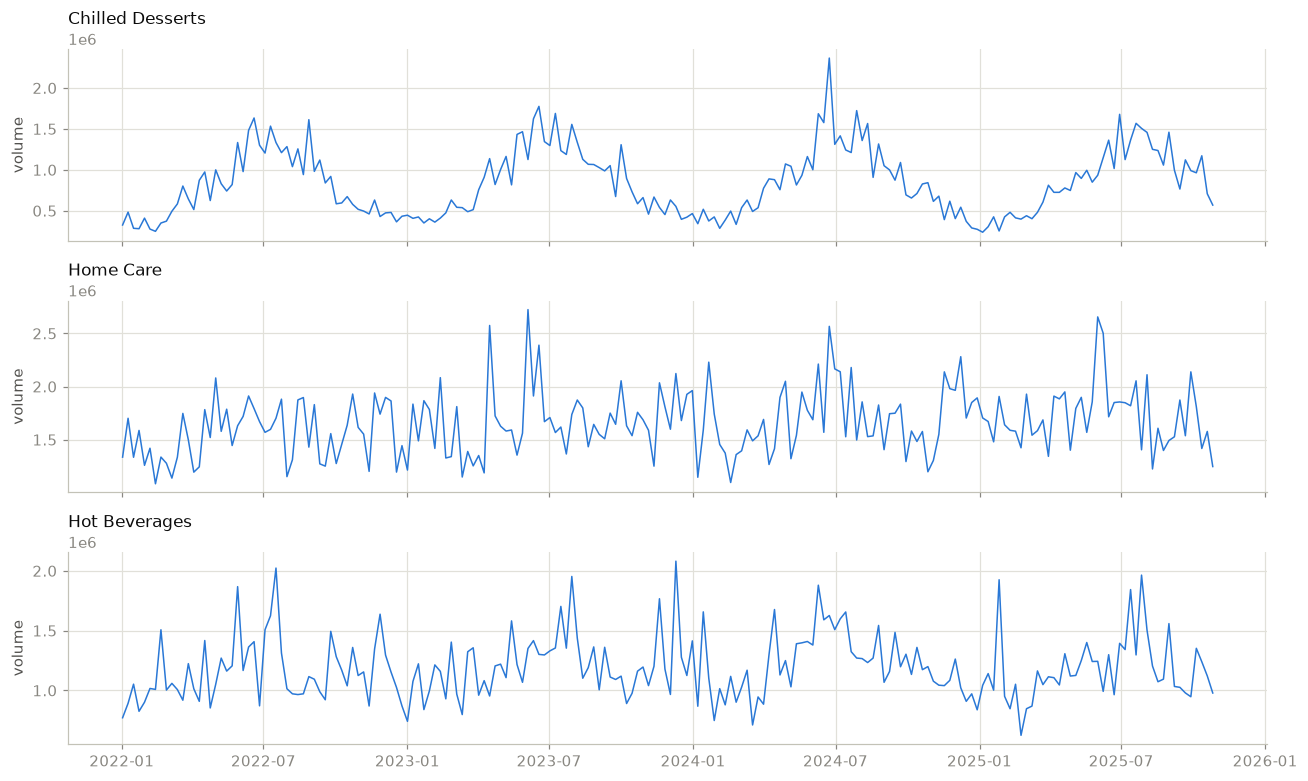

Volume summary by category:
                  count       mean       std        min        max
category                                                          
Chilled Desserts    200   840889.0  405725.0   237716.0  2365254.0
Home Care           200  1656204.0  307877.0  1084734.0  2724167.0
Hot Beverages       200  1191797.0  265802.0   624634.0  2080726.0


In [8]:
fig, axes = plt.subplots(len(CATEGORIES), 1, figsize=(12, 2.4 * len(CATEGORIES)),
                         sharex=True, squeeze=False)
for ax, cat in zip(axes.ravel(), CATEGORIES):
    s = panel[panel.category == cat]
    ax.plot(s["date"], s["volume"], color=SERIES[0], lw=1)
    ax.set_title(cat, loc="left", fontsize=11, color=INK_PRIMARY)
    ax.set_ylabel("volume")
plt.tight_layout(); plt.show()

print("Volume summary by category:")
print(panel.groupby("category")["volume"]
      .agg(["count", "mean", "std", "min", "max"]).round(0).to_string())

## §3. Feature engineering

The design matrix for one category is:

```
log(driver)  for each SELECTED driver
+ linear trend (in years)
+ Fourier pairs for the yearly cycle, K of them
+ holiday-period dummies
```

No category dummies and no shared terms, because each category is fitted entirely
on its own.

Fourier terms are keyed on **day of year**, not period number, so 53-week years do
not shift the phase and the same code works for weekly or monthly data.

In [9]:
def adstock(x, decay):
    """Carryover: a[t] = x[t] + decay * a[t-1]. Media does not spend and vanish.

    decay=0 returns the input unchanged, which is how a category says "my media has
    no carryover" without needing a separate code path.
    """
    if decay <= 0:
        return np.asarray(x, dtype=float)
    out = np.empty(len(x), dtype=float)
    carry = 0.0
    for i, v in enumerate(x):
        carry = v + decay * carry
        out[i] = carry
    return out


def apply_adstock(df, decay):
    """Apply one category's validated decay to every adstock-eligible driver.

    One decay per category rather than one per driver: fitting a separate
    carryover rate for every media line is usually more parameters than a single
    category's history supports.
    """
    out = df.sort_values("date").copy()
    for name in ADSTOCK_DRIVERS:
        if name in out.columns:
            out[name] = adstock(out[name].to_numpy(dtype=float), decay)
    return out


def log_driver(values, name):
    x = np.asarray(values, dtype=float)
    if DRIVERS[name]["transform"] == "log":
        return np.log(np.clip(x, 1e-6, None))
    return np.log1p(np.clip(x, 0.0, None))


def fourier_terms(dates, k):
    """K sin/cos pairs for the yearly cycle, keyed on day-of-year."""
    doy = pd.DatetimeIndex(dates).dayofyear.to_numpy(dtype=float)
    out = pd.DataFrame(index=range(len(doy)))
    for j in range(1, k + 1):
        out[f"sin{j}"] = np.sin(2 * np.pi * j * doy / 365.25)
        out[f"cos{j}"] = np.cos(2 * np.pi * j * doy / 365.25)
    return out


def holiday_flags(dates):
    """Dummies for the periods you named in HOLIDAY_WEEKS. Controls, not levers."""
    wk = pd.DatetimeIndex(dates).isocalendar().week.to_numpy(dtype=int)
    return pd.DataFrame({name: np.isin(wk, weeks).astype(float)
                         for name, weeks in HOLIDAY_WEEKS.items()},
                        index=range(len(wk)))


def fourier_cols(k):
    return [f"{f}{j}" for j in range(1, k + 1) for f in ("sin", "cos")]


def control_cols(k):
    """Everything that is not a driver. Controls explain WHEN volume happens;
    drivers explain WHY. Controls are never penalised and never edited."""
    return ["trend"] + fourier_cols(k) + HOLIDAY_COLS


def build_design(df, drivers, k, decay, t0):
    """The full design matrix for ONE category.

    `drivers` is that category's selected list -- a different length and a
    different membership for every category, which is the point.
    """
    df = apply_adstock(df, decay).reset_index(drop=True)

    X = pd.DataFrame(index=range(len(df)))
    for name in drivers:
        X[f"l_{name}"] = log_driver(df[name].to_numpy(), name)

    X["trend"] = (pd.DatetimeIndex(df["date"]) - t0).days.to_numpy() / 365.25
    for col, vals in fourier_terms(df["date"], k).items():
        X[col] = vals.to_numpy()
    if HOLIDAY_COLS:
        for col, vals in holiday_flags(df["date"]).items():
            X[col] = vals.to_numpy()
    return X


print("feature functions defined")

feature functions defined


## §4. The model

One model per category, a log-log ridge:

```
log(volume) = intercept
            + SUM_d  beta_d * log(driver_d)      <- the elasticities
            + trend + yearly seasonality + holiday periods
```

`beta_d` reads directly as an elasticity: the % change in volume for a 1% change
in that driver. Ridge rather than plain least squares because price, promo depth
and promo share move together in most real data, and shrinkage is the point.

Three deliberate choices:

- **Only driver coefficients are penalised.** Trend, seasonality and holidays are
  controls; shrinking them would distort the calendar to buy a smaller elasticity,
  which is backwards.
- **Coefficients carry the sign constraints you set in §1.**
- **Validation is per category** on expanding-window folds. Random k-fold would let
  the model train on next winter to predict last winter, which for a forecasting
  tool is cheating with extra steps.

In [10]:
def fit_ridge(X, y, alpha, penalise, lo, hi):
    """Sign-constrained ridge, solved as a bounded least-squares problem.

    The ridge penalty is applied by stacking sqrt(alpha)*I under the design and
    zeros under the response -- the standard Tikhonov trick -- which turns "ridge
    with bounds" into an ordinary bounded least-squares call. Both sides are
    centred first so the intercept is fitted but never penalised or constrained.
    """
    x_mean, y_mean = X.mean(axis=0), y.mean()
    Xc, yc = X - x_mean, y - y_mean

    A = np.vstack([Xc, np.sqrt(alpha) * np.diag(penalise)])
    b = np.concatenate([yc, np.zeros(X.shape[1])])
    res = lsq_linear(A, b, bounds=(lo, hi), method="bvls", max_iter=500)

    coef = res.x
    return coef, float(y_mean - x_mean @ coef)


def coef_bounds(cols):
    """Sign constraints per design column. Controls free; drivers follow §1."""
    lo, hi = [], []
    for c in cols:
        sign = DRIVERS[c[2:]]["sign"] if c.startswith("l_") else 0
        lo.append(-np.inf if sign <= 0 else 0.0)
        hi.append(np.inf if sign >= 0 else 0.0)
    return np.array(lo), np.array(hi)


def penalty_weights(cols):
    """Shrink elasticities, never the calendar."""
    return np.array([1.0 if c.startswith("l_") else 0.0 for c in cols])


def scale_cols(X):
    sd = X.std(axis=0, ddof=0)
    sd = np.where(sd < 1e-12, 1.0, sd)
    return X / sd, sd


def fit_design(X, y, alpha):
    """Fit a built design; returns raw (unscaled) coefficients and the intercept."""
    cols = list(X.columns)
    Xs, sd = scale_cols(X.to_numpy(dtype=float))
    lo, hi = coef_bounds(cols)
    coef_s, intercept = fit_ridge(Xs, y, alpha, penalty_weights(cols), lo, hi)
    return pd.Series(coef_s / sd, index=cols), intercept   # unscale -> elasticities


def time_folds(n, n_folds=None):
    """Expanding-window folds: always train on the past, test on the future."""
    n_folds = n_folds or CV_FOLDS
    edges = np.linspace(n // 2, n, n_folds + 1).astype(int)
    for i in range(n_folds):
        train, test = np.arange(0, edges[i]), np.arange(edges[i], edges[i + 1])
        if len(train) and len(test):
            yield train, test


def cv_rmse(df, drivers, k, decay, alpha, t0):
    """Mean out-of-fold RMSE in log space, for one category and one config.

    The design is built once over the whole history then sliced. Rebuilding it per
    fold would restart the adstock at each boundary and understate carryover.
    """
    X = build_design(df, drivers, k, decay, t0)
    y = np.log(df["volume"].to_numpy(dtype=float))

    errs = []
    for tr, te in time_folds(len(df)):
        coef, intercept = fit_design(X.iloc[tr], y[tr], alpha)
        pred = X.iloc[te].to_numpy() @ coef.to_numpy() + intercept
        errs.append(np.sqrt(np.mean((y[te] - pred) ** 2)))
    return float(np.mean(errs))


def choose_config(df, drivers, t0, grid=None):
    """Search the grid for this category's best (fourier_k, adstock_decay, alpha)."""
    grid = grid or GRID
    rows = []
    for k in grid["fourier_k"]:
        for decay in grid["adstock_decay"]:
            for alpha in grid["alpha"]:
                rows.append({"fourier_k": k, "adstock_decay": decay, "alpha": alpha,
                             "cv_rmse": cv_rmse(df, drivers, k, decay, alpha, t0)})
    table = pd.DataFrame(rows).sort_values("cv_rmse").reset_index(drop=True)
    best = table.iloc[0]
    return ({"fourier_k": int(best["fourier_k"]),
             "adstock_decay": float(best["adstock_decay"]),
             "alpha": float(best["alpha"])}, table)


def best_alpha(df, drivers, k, decay, t0, alphas=None):
    """Tune only the ridge strength, holding shape fixed. Used during selection."""
    alphas = alphas or GRID["alpha"]
    rmse, a = min((cv_rmse(df, drivers, k, decay, a, t0), a) for a in alphas)
    return a, rmse


print("model functions defined")

model functions defined


In [11]:
@dataclass
class CategoryModel:
    """One category's model. It knows nothing about any other category."""
    category: str
    drivers: list
    fourier_k: int
    adstock_decay: float
    alpha: float
    coef: pd.Series
    intercept: float
    t0: pd.Timestamp
    log_sd: pd.Series
    metrics: dict = field(default_factory=dict)
    selection: dict = field(default_factory=dict)

    @property
    def elasticities(self):
        return pd.Series({d: float(self.coef[f"l_{d}"]) for d in self.drivers})

    def design(self, df):
        return build_design(df, self.drivers, self.fourier_k, self.adstock_decay, self.t0)

    def predict(self, df):
        X = self.design(df)
        return np.exp(X[self.coef.index].to_numpy() @ self.coef.to_numpy() + self.intercept)

    def impacts(self):
        """How much each driver moves this category's volume, and which direction.

        `impact_pct` is the signed % volume change from a one-standard-deviation
        move, using that driver's own historic variation. It answers "how much does
        this lever actually matter here", which elasticity alone does not: a big
        elasticity on a driver that never moves is not a lever.
        """
        rows = []
        for d in self.drivers:
            e, sd = float(self.elasticities[d]), float(self.log_sd[d])
            rows.append({"driver": d, "label": DRIVERS[d]["label"],
                         "elasticity": e, "log_sd": sd,
                         "impact_pct": 100.0 * (np.exp(e * sd) - 1),
                         "direction": "increases volume" if e > 0 else "decreases volume"})
        out = pd.DataFrame(rows)
        out["abs_impact"] = out["impact_pct"].abs()
        return (out.sort_values("abs_impact", ascending=False)
                   .drop(columns="abs_impact").reset_index(drop=True))


def fit_category(df, category, drivers, config, t0):
    """Fit one category on the rows given. `df` must be that category only."""
    df = df.sort_values("date").reset_index(drop=True)
    k, decay, alpha = config["fourier_k"], config["adstock_decay"], config["alpha"]

    X = build_design(df, drivers, k, decay, t0)
    y = np.log(df["volume"].to_numpy(dtype=float))
    coef, intercept = fit_design(X, y, alpha)

    return CategoryModel(
        category=category, drivers=list(drivers), fourier_k=k, adstock_decay=decay,
        alpha=alpha, coef=coef, intercept=intercept, t0=t0,
        log_sd=pd.Series({d: float(X[f"l_{d}"].std(ddof=1)) for d in drivers}))


def score(model, df):
    """Accuracy of a fitted model on any slice of that category's data."""
    actual = df["volume"].to_numpy(dtype=float)
    pred = model.predict(df)
    resid_log = np.log(actual) - np.log(pred)
    ss_res = float(np.sum(resid_log ** 2))
    ss_tot = float(np.sum((np.log(actual) - np.log(actual).mean()) ** 2))
    return {"n_periods": int(len(df)),
            "mape": float(np.mean(np.abs(pred / actual - 1)) * 100),
            "wape": float(np.sum(np.abs(pred - actual)) / np.sum(actual) * 100),
            "r2_log": float(1 - ss_res / ss_tot) if ss_tot else float("nan"),
            "bias_pct": float((pred.sum() / actual.sum() - 1) * 100)}


print("CategoryModel defined")

CategoryModel defined


## §5. Feature selection, per category

Backward elimination scored on **expanding-window cross-validation**. Start with
every driver you specced. Repeatedly ask "what happens to out-of-fold error if I
drop this one?", and drop the cheapest — while it stays cheap.

In-sample fit could not do this job: adding a driver can only ever improve it, so
in-sample selection keeps everything and answers nothing.

Two guards stop pure error-chasing from building the wrong tool.

**The sign prior.** A driver whose *unconstrained* elasticity contradicts the sign
you set in §1 is removed before the search starts. Fitted unconstrained on
purpose — the disagreement is the signal, and a constrained fit would silently pin
the coefficient at zero and let the driver look fine. If you set every `sign` to
`0`, this does nothing.

**Lever protection.** This one is the reason the `controllable` flag exists. Your
price and a competitor's price usually move together, so out-of-fold error cannot
separate them, and the search will happily drop yours and keep theirs — the swap
costs nothing measurable. As a *forecast*, fine. As a *planning tool*, useless: it
deletes the one number you actually set and replaces it with a number you can only
watch.

So a `controllable` driver is protected from elimination when its estimated impact
clears `MATERIALITY_PCT`. The threshold is what keeps this from becoming blanket
protection — a controllable driver the model finds genuinely inert is still
dropped.

Selection runs on the **training rows only**. Selecting on all your history and
then reporting accuracy on the last slice of it leaks the test set into the
feature list and produces a number that means nothing.

In [12]:
def sign_check(df, drivers, k, decay, t0):
    """Drivers whose UNCONSTRAINED elasticity contradicts the prior set in §1."""
    X = build_design(df, drivers, k, decay, t0)
    y = np.log(df["volume"].to_numpy(dtype=float))

    cols = list(X.columns)
    Xs, sd = scale_cols(X.to_numpy(dtype=float))
    free_lo, free_hi = np.full(len(cols), -np.inf), np.full(len(cols), np.inf)
    coef_s, _ = fit_ridge(Xs, y, 1.0, penalty_weights(cols), free_lo, free_hi)
    coef = pd.Series(coef_s / sd, index=cols)

    bad = []
    for d in drivers:
        prior, e = DRIVERS[d]["sign"], float(coef[f"l_{d}"])
        if prior != 0 and np.sign(e) == -prior and abs(e) > 0.01:
            bad.append(d)
    return bad


def protected_drivers(df, kept, k, decay, alpha, t0):
    """Controllable levers the model finds material. Never eliminated."""
    m = fit_category(df, "tmp", kept,
                     {"fourier_k": k, "adstock_decay": decay, "alpha": alpha}, t0)
    impacts = m.impacts().set_index("driver")["impact_pct"].abs()
    return [d for d in kept
            if DRIVERS[d]["controllable"] and impacts.get(d, 0.0) >= MATERIALITY_PCT]


def backward_eliminate(df, drivers, k, decay, t0,
                       tolerance=None, verbose=False):
    """Drop drivers while out-of-fold error does not meaningfully worsen.

    `tolerance` is a fraction of the current CV RMSE. Every driver kept is one more
    series someone has to forecast, maintain and explain.
    """
    tolerance = SELECTION_TOLERANCE if tolerance is None else tolerance
    kept = list(drivers)
    alpha, rmse = best_alpha(df, kept, k, decay, t0)
    log = [{"step": 0, "removed": None, "n_drivers": len(kept),
            "cv_rmse": rmse, "alpha": alpha}]

    step = 0
    while len(kept) > 1:
        protected = protected_drivers(df, kept, k, decay, alpha, t0)
        removable = [d for d in kept if d not in protected]
        if not removable:
            break

        candidates = []
        for d in removable:
            a, r = best_alpha(df, [x for x in kept if x != d], k, decay, t0)
            candidates.append((r, d, a))
        candidates.sort()
        best_rmse, drop, best_a = candidates[0]

        if best_rmse > rmse * (1 + tolerance):
            break                                  # everything left is earning its place

        step += 1
        kept = [x for x in kept if x != drop]
        rmse, alpha = best_rmse, best_a
        log.append({"step": step, "removed": drop, "n_drivers": len(kept),
                    "cv_rmse": rmse, "alpha": alpha})
        if verbose:
            print(f"      drop {drop:<22} -> {len(kept):2d} drivers, cv_rmse {rmse:.5f}")

    return kept, pd.DataFrame(log)


def select_for_category(df, category, t0, verbose=True):
    """The full routine for one category. `df` is that category's TRAIN rows.

    Order matters. Shape is settled first with every driver present, so the search
    is not comparing driver sets across different seasonal models. Then drivers are
    eliminated. Then shape is re-validated on the survivors, because the right
    number of harmonics can change once drivers carrying part of the seasonality
    are gone.
    """
    candidates = list(DRIVER_NAMES)
    if verbose:
        print(f"    [1/4] tuning shape with all {len(candidates)} drivers ...")
    shape, _ = choose_config(df, candidates, t0)

    if verbose:
        print(f"          k={shape['fourier_k']}, decay={shape['adstock_decay']}, "
              f"alpha={shape['alpha']}")
        print("    [2/4] checking elasticity signs against your priors ...")
    wrong_sign = sign_check(df, candidates, shape["fourier_k"], shape["adstock_decay"], t0)
    survivors = [d for d in candidates if d not in wrong_sign]
    if verbose:
        print(f"          dropped for wrong sign: {', '.join(wrong_sign) or 'none'}")
        print("    [3/4] backward elimination on out-of-fold error ...")

    kept, log = backward_eliminate(df, survivors, shape["fourier_k"],
                                   shape["adstock_decay"], t0, verbose=verbose)

    if verbose:
        print(f"    [4/4] re-tuning shape on the {len(kept)} selected drivers ...")
    final, grid = choose_config(df, kept, t0)
    if verbose:
        print(f"          k={final['fourier_k']}, decay={final['adstock_decay']}, "
              f"alpha={final['alpha']}")

    return {"category": category, "selected": kept,
            "dropped": [d for d in candidates if d not in kept],
            "dropped_wrong_sign": wrong_sign, "config": final,
            "elimination_log": log, "grid": grid}


print("selection functions defined")

selection functions defined


## §6–7. Fit every category: select, validate, test, refit

Three hyperparameters are tuned per category:

| | what it controls |
|---|---|
| `fourier_k` | how many harmonics the yearly seasonality gets |
| `adstock_decay` | how long media carries over |
| `alpha` | ridge strength on the elasticities |

Then: the test score comes from a model that saw neither the test periods nor —
crucially — let them influence which features exist. The model that ships is
refitted on the full history with the same recipe, because holding out your most
recent year forever, just to preserve a number you have already recorded, throws
away your most relevant data.

This is the slow cell. Roughly `len(categories) × 30s` on a few hundred periods.

In [13]:
models, rows = {}, []
for c in CATEGORIES:
    print(f"\n{'-' * 70}\n{c}\n{'-' * 70}")
    d = panel[panel.category == c].sort_values("date").reset_index(drop=True)
    cutc = d.date.max() - pd.Timedelta(days=int(TEST_PERIODS * 365.25 / PERIODS_PER_YEAR))
    tr, te = d[d.date <= cutc], d[d.date > cutc]
    print(f"  train {len(tr)} periods, test {len(te)} periods")

    r = select_for_category(tr, c, t0)
    print(f"  selected {len(r['selected'])}/{len(DRIVER_NAMES)}: "
          f"{', '.join(r['selected'])}")
    print(f"  dropped: {', '.join(r['dropped']) or 'none'}")

    tm = fit_category(tr, c, r["selected"], r["config"], t0)   # honest test score
    fm = fit_category(d, c, r["selected"], r["config"], t0)    # the model that ships
    fm.metrics = {"train": score(tm, tr), "test": score(tm, te)}
    fm.selection = r
    models[c] = fm

    print(f"  test MAPE {fm.metrics['test']['mape']:5.2f}%  "
          f"R2(log) {fm.metrics['test']['r2_log']:.3f}  "
          f"bias {fm.metrics['test']['bias_pct']:+.2f}%")

    rows.append({"category": c, "drivers": len(r["selected"]), **r["config"],
                 "train MAPE %": fm.metrics["train"]["mape"],
                 "test MAPE %": fm.metrics["test"]["mape"],
                 "test R2 log": fm.metrics["test"]["r2_log"],
                 "test bias %": fm.metrics["test"]["bias_pct"]})

summary = pd.DataFrame(rows).set_index("category").round(3)
print(f"\n{'=' * 70}\nSUMMARY\n{'=' * 70}")
summary


----------------------------------------------------------------------
Chilled Desserts
----------------------------------------------------------------------
  train 148 periods, test 52 periods
    [1/4] tuning shape with all 8 drivers ...


          k=1, decay=0.0, alpha=0.01
    [2/4] checking elasticity signs against your priors ...
          dropped for wrong sign: distribution_acv
    [3/4] backward elimination on out-of-fold error ...
    [4/4] re-tuning shape on the 7 selected drivers ...


          k=1, decay=0.0, alpha=0.01
  selected 7/8: avg_price, competitor_price, promo_depth, promo_share, tv_grps, digital_spend, avg_temp_c
  dropped: distribution_acv
  test MAPE  8.74%  R2(log) 0.964  bias +8.19%

----------------------------------------------------------------------
Home Care
----------------------------------------------------------------------
  train 148 periods, test 52 periods
    [1/4] tuning shape with all 8 drivers ...


          k=1, decay=0.0, alpha=1.0
    [2/4] checking elasticity signs against your priors ...
          dropped for wrong sign: none
    [3/4] backward elimination on out-of-fold error ...
      drop digital_spend          ->  7 drivers, cv_rmse 0.04974
      drop avg_temp_c             ->  6 drivers, cv_rmse 0.04945
    [4/4] re-tuning shape on the 6 selected drivers ...


          k=1, decay=0.0, alpha=1.0
  selected 6/8: avg_price, competitor_price, promo_depth, promo_share, distribution_acv, tv_grps
  dropped: digital_spend, avg_temp_c
  test MAPE  5.04%  R2(log) 0.851  bias -2.04%

----------------------------------------------------------------------
Hot Beverages
----------------------------------------------------------------------
  train 148 periods, test 52 periods
    [1/4] tuning shape with all 8 drivers ...


          k=1, decay=0.0, alpha=3.0
    [2/4] checking elasticity signs against your priors ...
          dropped for wrong sign: none
    [3/4] backward elimination on out-of-fold error ...
      drop avg_temp_c             ->  7 drivers, cv_rmse 0.05161
    [4/4] re-tuning shape on the 7 selected drivers ...


          k=1, decay=0.0, alpha=3.0
  selected 7/8: avg_price, competitor_price, promo_depth, promo_share, distribution_acv, tv_grps, digital_spend
  dropped: avg_temp_c
  test MAPE  8.77%  R2(log) 0.769  bias +7.78%

SUMMARY


,drivers,fourier_k,adstock_decay,alpha,train MAPE %,test MAPE %,test R2 log,test bias %
category,,,,,,,,
Chilled Desserts,7,1,0.0,0.01,3.158,8.739,0.964,8.191
Home Care,6,1,0.0,1.00,3.615,5.043,0.851,-2.040
Hot Beverages,7,1,0.0,3.00,3.309,8.765,0.769,7.779


**How to read the test columns.** MAPE is average weekly error — it will always
look worse than an annual number because weekly noise does not cancel. `bias %` is
total predicted vs total actual over the test window, and it is the one that
matters for planning: a model can have high MAPE and near-zero bias, which is
fine, or low MAPE and a persistent 8% bias, which is not.

A large bias usually means a persistent shift the model has no column for — a
distribution change, a competitor launch, a supply constraint — not a broken model.

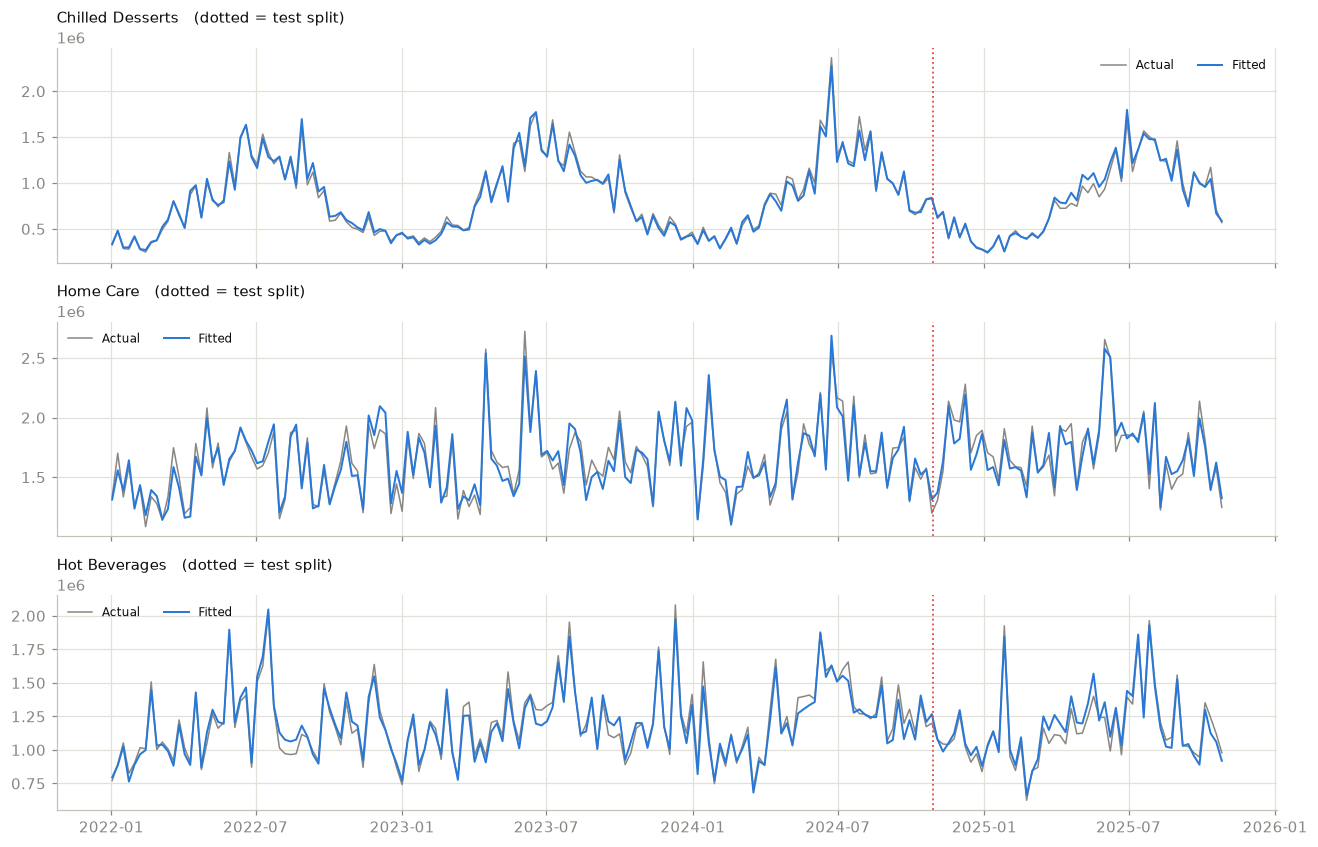

In [14]:
fig, axes = plt.subplots(len(CATEGORIES), 1, figsize=(12, 2.6 * len(CATEGORIES)),
                         sharex=True, squeeze=False)
for ax, c in zip(axes.ravel(), CATEGORIES):
    d = panel[panel.category == c].sort_values("date")
    cutc = d.date.max() - pd.Timedelta(days=int(TEST_PERIODS * 365.25 / PERIODS_PER_YEAR))
    ax.plot(d["date"], d["volume"], color=INK_MUTED, lw=1, label="Actual")
    ax.plot(d["date"], models[c].predict(d), color=SERIES[0], lw=1.3, label="Fitted")
    ax.axvline(cutc, color=NEG, ls=":", lw=1.2)
    ax.set_title(f"{c}   (dotted = test split)", loc="left", fontsize=10)
    ax.legend(frameon=False, ncol=2, fontsize=8)
plt.tight_layout(); plt.show()

In [15]:
print("Validation grid, top 8 for each category:\n")
for c in CATEGORIES:
    print(f"{c}:")
    print(models[c].selection["grid"].head(8).to_string(index=False))
    print()

Validation grid, top 8 for each category:

Chilled Desserts:
 fourier_k  adstock_decay  alpha  cv_rmse
         1            0.0   0.01 0.052708
         1            0.0   0.10 0.052882
         2            0.0   0.01 0.053682
         2            0.0   0.10 0.053760
         1            0.0   0.50 0.053786
         2            0.0   0.50 0.054312
         1            0.0   1.00 0.055105
         2            0.0   1.00 0.055327

Home Care:
 fourier_k  adstock_decay  alpha  cv_rmse
         1            0.0    1.0 0.049447
         1            0.0    3.0 0.050316
         1            0.0    0.5 0.050519
         2            0.0    1.0 0.052646
         3            0.0    1.0 0.053099
         3            0.0    0.5 0.053230
         2            0.0    0.5 0.053333
         1            0.0   10.0 0.054133

Hot Beverages:
 fourier_k  adstock_decay  alpha  cv_rmse
         1            0.0    3.0 0.051610
         2            0.0    3.0 0.054066
         1            0.0   1

## §8. Driver impact — which levers matter, and which way

Two numbers, and the difference matters:

- **elasticity** — % change in volume for a 1% change in the driver.
- **impact** — % change in volume for a *one-standard-deviation* move, using that
  category's own history.

Elasticity alone overstates a driver that never moves. A −2.0 price elasticity on
a price that varies 3% is a smaller lever than a +0.05 media elasticity on a budget
that swings by half. **Plan against impact; sanity-check elasticity.**

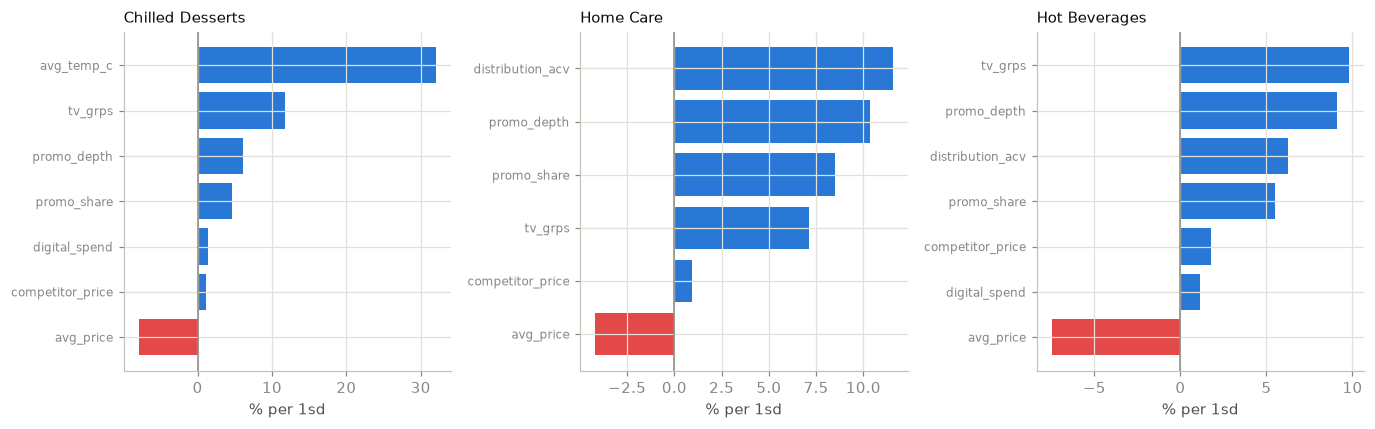


Chilled Desserts:
          driver            label  elasticity  log_sd  impact_pct        direction
      avg_temp_c  Avg Temperature       0.444   0.626      32.076 increases volume
         tv_grps          TV GRPs       0.050   2.207      11.768 increases volume
       avg_price    Average Price      -2.121   0.039      -7.934 decreases volume
     promo_depth      Promo Depth       0.372   0.158       6.060 increases volume
     promo_share      Promo Share       0.236   0.193       4.654 increases volume
   digital_spend    Digital Spend       0.038   0.368       1.397 increases volume
competitor_price Competitor Price       0.368   0.029       1.080 increases volume

Home Care:
          driver            label  elasticity  log_sd  impact_pct        direction
distribution_acv Distribution ACV       2.152   0.051      11.550 increases volume
     promo_depth      Promo Depth       0.531   0.186      10.368 increases volume
     promo_share      Promo Share       0.387   0.211   

In [16]:
fig, axes = plt.subplots(1, len(CATEGORIES), figsize=(4.2 * len(CATEGORIES), 4),
                         squeeze=False)
for ax, c in zip(axes.ravel(), CATEGORIES):
    imp = models[c].impacts().sort_values("impact_pct")
    ax.barh(range(len(imp)), imp["impact_pct"],
            color=[POS if v > 0 else NEG for v in imp["impact_pct"]])
    ax.set_yticks(range(len(imp)), imp["driver"], fontsize=8)
    ax.axvline(0, color=INK_MUTED, lw=1)
    ax.set_title(c, loc="left", fontsize=10)
    ax.set_xlabel("% per 1sd")
plt.tight_layout(); plt.show()

for c in CATEGORIES:
    print(f"\n{c}:")
    print(models[c].impacts().round(3).to_string(index=False))

### §8b. Coefficient stability — your substitute for ground truth

With synthetic data you check estimates against the truth. You have no truth, so
check them against **themselves over time**.

Each model is refitted on progressively longer windows — 60%, 70%, 80%, 90% and
100% of history. A driver whose elasticity is real settles down and stays put. One
that swings, flips sign, or drifts steadily with the window is telling you the
data cannot pin it down, and you should not plan against its number no matter how
good the holdout looks.

**Read the `range` column.** A range comparable to the coefficient itself means
the estimate is noise wearing a decimal point.

In [17]:
def coefficient_stability(df, category, drivers, config, t0,
                          fractions=(0.6, 0.7, 0.8, 0.9, 1.0)):
    """Refit on expanding windows and report how much each elasticity moves."""
    df = df.sort_values("date").reset_index(drop=True)
    rows = {}
    for f in fractions:
        sub = df.iloc[: int(len(df) * f)]
        m = fit_category(sub, category, drivers, config, t0)
        rows[f"{int(f * 100)}%"] = m.elasticities
    out = pd.DataFrame(rows)
    out["range"] = out.max(axis=1) - out.min(axis=1)
    out["mean"] = out[list(rows)].mean(axis=1)
    out["flips_sign"] = (out[list(rows)].min(axis=1) < 0) & (out[list(rows)].max(axis=1) > 0)
    # A range bigger than half the average level is a coefficient you cannot trust.
    out["verdict"] = np.where(
        out["flips_sign"], "UNSTABLE (flips sign)",
        np.where(out["range"] > 0.5 * out["mean"].abs(), "shaky", "stable"))
    return out


stability = {}
for c in CATEGORIES:
    d = panel[panel.category == c]
    stability[c] = coefficient_stability(d, c, models[c].drivers,
                                         models[c].selection["config"], t0)
    print(f"\n{c}:")
    print(stability[c].round(3).to_string())


Chilled Desserts:
                    60%    70%    80%    90%   100%  range   mean  flips_sign verdict
avg_price        -2.141 -2.062 -2.142 -2.049 -2.121  0.093 -2.103       False  stable
competitor_price  0.328  0.357  0.367  0.361  0.368  0.039  0.356       False  stable
promo_depth       0.340  0.356  0.360  0.376  0.372  0.036  0.361       False  stable
promo_share       0.242  0.240  0.236  0.247  0.236  0.011  0.240       False  stable
tv_grps           0.049  0.050  0.050  0.050  0.050  0.001  0.050       False  stable
digital_spend     0.041  0.037  0.039  0.041  0.038  0.004  0.039       False  stable
avg_temp_c        0.423  0.421  0.441  0.439  0.444  0.023  0.434       False  stable

Home Care:
                    60%    70%    80%    90%   100%  range   mean  flips_sign verdict
avg_price        -0.924 -0.909 -0.924 -0.943 -1.032  0.123 -0.947       False  stable
competitor_price  0.347  0.350  0.230  0.309  0.312  0.119  0.310       False  stable
promo_depth       0.522

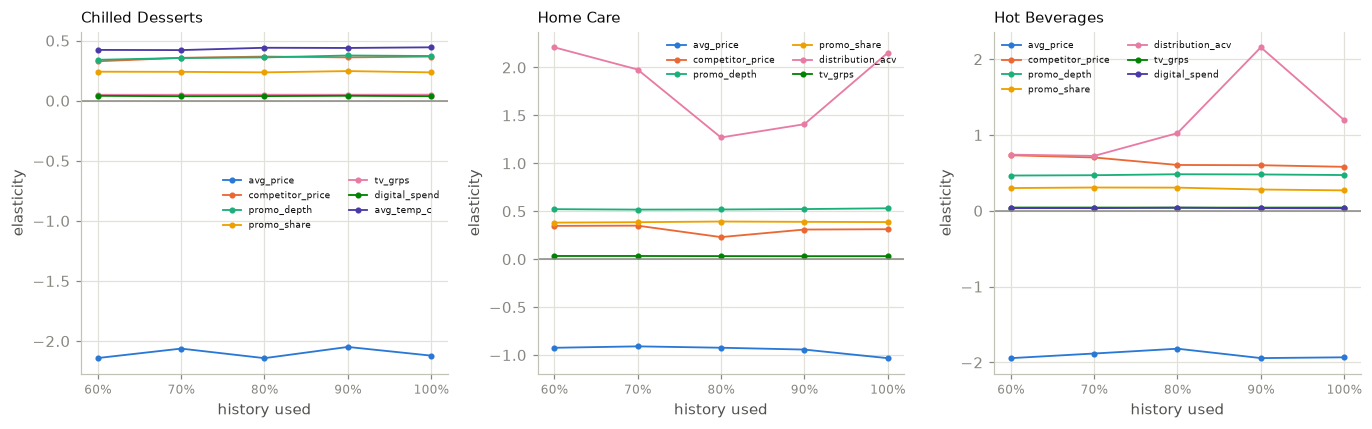

Drivers to treat with caution:
  Chilled Desserts       none -- all stable
  Home Care              distribution_acv
  Hot Beverages          distribution_acv


In [18]:
fig, axes = plt.subplots(1, len(CATEGORIES), figsize=(4.2 * len(CATEGORIES), 4),
                         squeeze=False)
for ax, c in zip(axes.ravel(), CATEGORIES):
    s = stability[c]
    wins = [col for col in s.columns if col.endswith("%")]
    for i, d in enumerate(s.index):
        ax.plot(range(len(wins)), s.loc[d, wins].to_numpy(),
                marker="o", ms=3, lw=1.2, color=SERIES[i % len(SERIES)], label=d)
    ax.axhline(0, color=INK_MUTED, lw=1)
    ax.set_xticks(range(len(wins)), wins, fontsize=8)
    ax.set_xlabel("history used"); ax.set_ylabel("elasticity")
    ax.set_title(c, loc="left", fontsize=10)
    ax.legend(frameon=False, fontsize=6, ncol=2)
plt.tight_layout(); plt.show()

flagged = {c: list(s.index[s["verdict"] != "stable"]) for c, s in stability.items()}
print("Drivers to treat with caution:")
for c, ds in flagged.items():
    print(f"  {c:<22} {', '.join(ds) or 'none -- all stable'}")

### §8c. Does the model agree with what you already believe?

The last check available without ground truth. For every driver you gave a
non-zero `sign` in §1, does the fitted elasticity point the right way, and is the
magnitude in a range you would defend to someone who knows the category?

Sign agreement is partly circular — the constraints enforce it — so the useful
columns are **magnitude** and whether a driver was *dropped for wrong sign*
during selection. A driver that had to be dropped for contradicting your prior is
the model telling you that, in this data, it cannot see the effect you believe in.

In [19]:
rows = []
for c in CATEGORIES:
    m = models[c]
    for d in DRIVER_NAMES:
        prior = DRIVERS[d]["sign"]
        if d in m.drivers:
            e = float(m.elasticities[d])
            status = ("agrees" if prior == 0 or np.sign(e) == prior else "CONTRADICTS")
        elif d in m.selection["dropped_wrong_sign"]:
            e, status = np.nan, "dropped: contradicted your prior"
        else:
            e, status = np.nan, "dropped: not earning its place"
        rows.append({"category": c, "driver": d,
                     "your prior": {1: "+", -1: "-", 0: "none"}[prior],
                     "elasticity": e, "status": status})

agreement = pd.DataFrame(rows)
print("Sign agreement and selection outcome:\n")
print(agreement.pivot(index="driver", columns="category", values="status").to_string())

concern = agreement[agreement["status"].str.contains("CONTRADICT|contradicted")]
print("\nWorth a conversation before anyone plans on this:")
print(concern.to_string(index=False) if len(concern)
      else "  nothing -- every retained driver agrees with your priors")

Sign agreement and selection outcome:

category                          Chilled Desserts                       Home Care                   Hot Beverages
driver                                                                                                            
avg_price                                   agrees                          agrees                          agrees
avg_temp_c                                  agrees  dropped: not earning its place  dropped: not earning its place
competitor_price                            agrees                          agrees                          agrees
digital_spend                               agrees  dropped: not earning its place                          agrees
distribution_acv  dropped: contradicted your prior                          agrees                          agrees
promo_depth                                 agrees                          agrees                          agrees
promo_share                              

## §9. Forecast the selected drivers, then the baseline

Each `(category, driver)` pair is forecast on its own — the same driver can look
completely different for two categories, and nothing forces them to agree.

Only **selected** drivers are forecast. That is most of the practical payoff of
doing selection first: the forecasting work, and the maintenance of it, scales
with the drivers you actually use rather than with everything you collect.

**These are naive extrapolations.** In practice you will replace them with your own
plan — which is exactly what §10 is for. Forecasts are held inside an envelope
around observed history, because a long extrapolation of a mild trend otherwise
drifts somewhere nobody would sign off on.

In [20]:
for _name in ("cmdstanpy", "prophet"):
    _log = logging.getLogger(_name)
    _log.setLevel(logging.CRITICAL); _log.handlers.clear(); _log.propagate = False

try:
    from prophet import Prophet
    HAS_PROPHET = True
except Exception:
    HAS_PROPHET = False


def future_periods(n=None):
    n = n or FORECAST_PERIODS
    step = pd.Timedelta(days=365.25 / PERIODS_PER_YEAR)
    return pd.date_range(panel["date"].max() + step, periods=n, freq=FREQ)


def prophet_forecast(dates, y, horizon):
    m = Prophet(yearly_seasonality=8, weekly_seasonality=False,
                daily_seasonality=False, seasonality_mode="additive",
                changepoint_prior_scale=0.05)
    m.fit(pd.DataFrame({"ds": pd.DatetimeIndex(dates), "y": y}))
    fut = m.make_future_dataframe(periods=horizon, freq=FREQ)
    return m.predict(fut).tail(horizon)["yhat"].to_numpy()


def fallback_forecast(dates, y, horizon):
    """Linear trend over the last two cycles plus a period-of-year index."""
    n = len(y)
    t = np.arange(n, dtype=float)
    window = min(int(2 * PERIODS_PER_YEAR), n)
    slope, intercept = np.polyfit(t[-window:], y[-window:], 1)

    resid = y - (intercept + slope * t)
    wk = pd.DatetimeIndex(dates).isocalendar().week.to_numpy(dtype=int)
    index = {w: resid[wk == w].mean() for w in np.unique(wk)}

    fut = future_periods(horizon)
    ft = np.arange(n, n + horizon, dtype=float)
    seasonal = np.array([index.get(w, 0.0)
                         for w in fut.isocalendar().week.to_numpy(dtype=int)])
    return intercept + slope * ft + seasonal


def keep_plausible(name, history, fc):
    """Hold the forecast inside an envelope around what has been observed."""
    lo, hi = float(history.min()), float(history.max())
    span = max(hi - lo, 1e-9)
    fc = np.clip(fc, lo - 0.30 * span, hi + 0.30 * span)
    if DRIVERS[name]["transform"] == "log":
        fc = np.clip(fc, max(lo * 0.5, 1e-6), None)   # strictly positive for log()
    else:
        fc = np.clip(fc, 0.0, None)
    return fc


def forecast_one(dates, y, name, horizon):
    fit = prophet_forecast if HAS_PROPHET else fallback_forecast
    try:
        fc = fit(dates, y, horizon)
    except Exception:
        fc = fallback_forecast(dates, y, horizon)
    return keep_plausible(name, np.asarray(y, dtype=float), fc)


def forecast_selected(panel, selected, horizon=None, verbose=True):
    """Forecast every (category, selected driver) pair.

    Drivers a category did not select come back as NaN -- explicitly absent rather
    than silently zero, so nothing downstream treats "not used" as "zero".
    """
    horizon = horizon or FORECAST_PERIODS
    fut = future_periods(horizon)
    rows = pd.DataFrame([(d, c) for c in CATEGORIES for d in fut],
                        columns=["date", "category"])
    for name in DRIVER_NAMES:
        rows[name] = np.nan

    for c in CATEGORIES:
        hist = panel[panel.category == c].sort_values("date")
        mask = (rows["category"] == c).to_numpy()
        if verbose:
            print(f"  {c:<24} {len(selected[c])} drivers")
        for name in selected[c]:
            rows.loc[mask, name] = forecast_one(
                hist["date"], hist[name].to_numpy(dtype=float), name, horizon)
    return rows.sort_values(["category", "date"]).reset_index(drop=True)


print(f"Forecasting {FORECAST_PERIODS} periods at {FREQ} (prophet={HAS_PROPHET})")
driver_fc = forecast_selected(panel, {c: m.drivers for c, m in models.items()})
print(f"\n{len(driver_fc)} forecast rows, "
      f"{driver_fc['date'].min().date()} -> {driver_fc['date'].max().date()}")

16:11:48 - cmdstanpy - INFO - Chain [1] start processing


16:11:48 - cmdstanpy - INFO - Chain [1] done processing


16:11:48 - cmdstanpy - INFO - Chain [1] start processing


16:11:48 - cmdstanpy - INFO - Chain [1] done processing


Forecasting 104 periods at W-SUN (prophet=True)
  Chilled Desserts         7 drivers


...

16:11:49 - cmdstanpy - INFO - Chain [1] start processing


16:11:49 - cmdstanpy - INFO - Chain [1] done processing


16:11:49 - cmdstanpy - INFO - Chain [1] start processing


16:11:49 - cmdstanpy - INFO - Chain [1] done processing



312 forecast rows, 2025-11-02 -> 2027-10-24


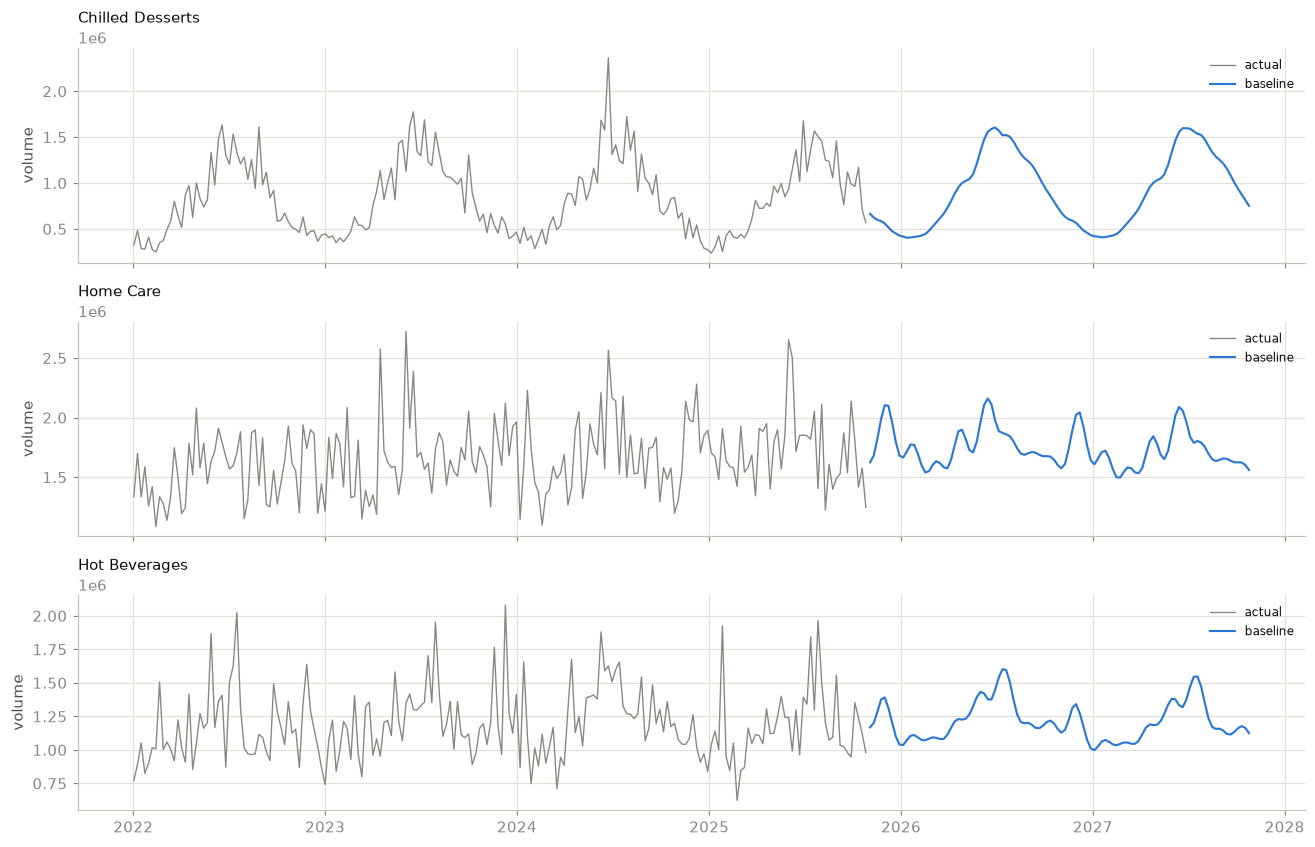

Baseline volume over the forecast horizon:
category
Chilled Desserts     95331334.0
Home Care           181371530.0
Hot Beverages       126257655.0


In [21]:
def predict_future(model, history, future):
    """Predict the future periods with history prepended, then return the future.

    History is always prepended so carryover crosses the forecast seam correctly.
    Predicting the future rows alone would restart adstock at zero and understate
    the first periods of any media plan.
    """
    cols = ["date"] + model.drivers
    combined = pd.concat([history[cols], future[cols]], ignore_index=True)
    combined = combined.sort_values("date").reset_index(drop=True)

    combined["volume_pred"] = model.predict(combined)
    adstocked = apply_adstock(combined, model.adstock_decay).reset_index(drop=True)
    for d in model.drivers:
        combined[f"l_{d}"] = log_driver(adstocked[d].to_numpy(), d)

    return combined[combined["date"] > history["date"].max()].reset_index(drop=True)


def baseline_table(model, panel, driver_fc):
    """History and forecast in one sheet -- the file you hand to a planner.

    Only this category's SELECTED drivers appear. A planner cannot edit a driver
    the model does not use, because the tool would silently ignore it.
    """
    c = model.category
    hist = panel[panel.category == c].sort_values("date").reset_index(drop=True)
    fut = predict_future(model, hist,
                         driver_fc[driver_fc.category == c].sort_values("date"))

    h = pd.DataFrame({"date": hist["date"], "category": c, "period": "history",
                      "volume_actual": hist["volume"].to_numpy(),
                      "volume_baseline": model.predict(hist)})
    f = pd.DataFrame({"date": fut["date"], "category": c, "period": "forecast",
                      "volume_actual": np.nan,
                      "volume_baseline": fut["volume_pred"].to_numpy()})
    for d in model.drivers:
        h[d] = hist[d].to_numpy()
        f[d] = fut[d].to_numpy()
    return pd.concat([h, f], ignore_index=True)


baseline = pd.concat([baseline_table(models[c], panel, driver_fc) for c in CATEGORIES],
                     ignore_index=True)

fig, axes = plt.subplots(len(CATEGORIES), 1, figsize=(12, 2.6 * len(CATEGORIES)),
                         sharex=True, squeeze=False)
for ax, c in zip(axes.ravel(), CATEGORIES):
    b = baseline[baseline.category == c]
    h, f = b[b.period == "history"], b[b.period == "forecast"]
    ax.plot(h["date"], h["volume_actual"], color=INK_MUTED, lw=0.9, label="actual")
    ax.plot(f["date"], f["volume_baseline"], color=SERIES[0], lw=1.4, label="baseline")
    ax.set_title(c, loc="left", fontsize=10); ax.set_ylabel("volume")
    ax.legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.show()

print("Baseline volume over the forecast horizon:")
print(baseline[baseline.period == "forecast"].groupby("category")["volume_baseline"]
      .sum().round(0).to_string())

## §10. Scenarios

The loop this is built for:

```
export    ->  a CSV of one category's drivers, history and forecast together
edit      ->  in Excel, by whoever owns the plan
re-import ->  the edited forecast rows become the scenario
```

A file rather than sliders, because a slider can only say "everything moves by
X%". A real plan is "price holds until March then rises 4%, and we pull the May
display event forward two weeks" — a column of numbers.

Only `period == 'forecast'` rows are read back. History is context for carryover;
editing it would move the actuals line, which is not a scenario.

Below, the edit is done in pandas. Swap in `pd.read_csv("edited.csv")` and it is
the identical code path.

In [22]:
def validate_scenario(edited, model, driver_fc):
    """Return a list of problems with an edited file. Empty list means usable."""
    problems = []
    for col in ["date", "period"]:
        if col not in edited.columns:
            problems.append(f"missing required column `{col}`")
    if problems:
        return problems

    missing = [d for d in model.drivers if d not in edited.columns]
    if missing:
        problems.append(f"missing driver columns: {', '.join(missing)}")

    fut = edited[edited["period"] == "forecast"]
    if fut.empty:
        problems.append("no rows with period='forecast' -- nothing to plan")
        return problems

    expected = set(pd.DatetimeIndex(
        driver_fc[driver_fc.category == model.category]["date"]))
    got = set(pd.DatetimeIndex(fut["date"]))
    if got - expected:
        problems.append(f"{len(got - expected)} forecast dates are not in the horizon")
    if expected - got:
        problems.append(f"{len(expected - got)} forecast periods are missing")

    for d in model.drivers:
        if d in fut.columns:
            vals = pd.to_numeric(fut[d], errors="coerce")
            if vals.isna().any():
                problems.append(f"`{d}` has {int(vals.isna().sum())} blank/non-numeric values")
            elif (vals < 0).any():
                problems.append(f"`{d}` has negative values")
    return problems


def run_scenario(model, panel, driver_fc, edited):
    """Baseline vs an edited driver plan, with a per-driver waterfall."""
    c = model.category
    hist = panel[panel.category == c].sort_values("date")
    base_fut = driver_fc[driver_fc.category == c].sort_values("date")

    scen_fut = edited[edited["period"] == "forecast"].copy()
    scen_fut["date"] = pd.to_datetime(scen_fut["date"])
    scen_fut = scen_fut.sort_values("date").reset_index(drop=True)
    for d in model.drivers:
        scen_fut[d] = pd.to_numeric(scen_fut[d], errors="coerce")

    base = predict_future(model, hist, base_fut)
    scen = predict_future(model, hist, scen_fut)

    paths = pd.DataFrame({"date": base["date"],
                          "baseline": base["volume_pred"].to_numpy(),
                          "scenario": scen["volume_pred"].to_numpy()})
    paths["delta"] = paths["scenario"] - paths["baseline"]

    # Allocate the total delta across drivers in proportion to their log
    # contributions, so the parts sum exactly to the whole.
    dlog = pd.DataFrame(index=base.index)
    for d in model.drivers:
        dlog[d] = float(model.elasticities[d]) * (
            scen[f"l_{d}"].to_numpy() - base[f"l_{d}"].to_numpy())
    total_dlog = dlog.sum(axis=1).to_numpy()
    denom = np.where(np.abs(total_dlog) < 1e-12, np.nan, total_dlog)
    delta = paths["delta"].to_numpy()

    rows = []
    for d in model.drivers:
        share = np.where(np.isnan(denom), 0.0, dlog[d].to_numpy() / denom)
        v = float(np.nansum(delta * share))
        if abs(v) > 1e-6:
            rows.append({"driver": d, "label": DRIVERS[d]["label"], "delta_volume": v})

    total_base = float(paths["baseline"].sum())
    total_scen = float(paths["scenario"].sum())
    wf = pd.DataFrame(rows, columns=["driver", "label", "delta_volume"])
    if len(wf):
        wf["delta_pct"] = 100.0 * wf["delta_volume"] / total_base
        wf = wf.sort_values("delta_volume", key=abs, ascending=False).reset_index(drop=True)

    changes = []
    for d in model.drivers:
        b, s = base_fut[d].to_numpy(dtype=float), scen_fut[d].to_numpy(dtype=float)
        if len(b) == len(s) and not np.allclose(b, s, rtol=1e-9, atol=1e-12):
            changes.append({"driver": d, "label": DRIVERS[d]["label"],
                            "baseline_avg": float(np.mean(b)),
                            "scenario_avg": float(np.mean(s)),
                            "pct_change": float((np.mean(s) / np.mean(b) - 1) * 100),
                            "periods_changed": int(np.sum(~np.isclose(b, s, rtol=1e-9)))})

    return {"paths": paths, "waterfall": wf, "changes": pd.DataFrame(changes),
            "summary": {"baseline_volume": total_base, "scenario_volume": total_scen,
                        "delta_volume": total_scen - total_base,
                        "delta_pct": 100.0 * (total_scen / total_base - 1)}}


print("scenario functions defined")

scenario functions defined


In [23]:
# ---- build a scenario ----------------------------------------------------
# Replace this block with: edited = pd.read_csv("your_edited_plan.csv")

cat = CATEGORIES[0]
m = models[cat]
edited = baseline[baseline.category == cat].copy()
fut = edited["period"] == "forecast"

# Example plan: price up 4% in the second year, media up 50% in summer periods.
second_year = fut & (edited["date"] > edited.loc[fut, "date"].min()
                     + pd.Timedelta(days=365))
if "avg_price" in m.drivers:
    edited.loc[second_year, "avg_price"] *= 1.04
if "tv_grps" in m.drivers:
    edited.loc[fut & edited["date"].dt.month.isin([5, 6, 7]), "tv_grps"] *= 1.5

problems = validate_scenario(edited, m, driver_fc)
print("Validation:", problems or "file is usable")

r = run_scenario(m, panel, driver_fc, edited)
s = r["summary"]
print(f"\n{cat}")
print(f"  Baseline  {s['baseline_volume']:>16,.0f}")
print(f"  Scenario  {s['scenario_volume']:>16,.0f}")
print(f"  Change    {s['delta_volume']:>+16,.0f}   ({s['delta_pct']:+.2f}%)")

Validation: file is usable

Chilled Desserts
  Baseline        95,331,334
  Scenario        92,263,775
  Change          -3,067,559   (-3.22%)


What changed in the plan:


,driver,label,baseline_avg,scenario_avg,pct_change,periods_changed
0,avg_price,Average Price,4.98,5.08,1.99,51
1,tv_grps,TV GRPs,47.04,51.78,10.08,26



Where the volume difference comes from:


,driver,label,delta_volume,delta_pct
0,avg_price,Average Price,-3779587.5,-4.0
1,tv_grps,TV GRPs,712028.7,0.7


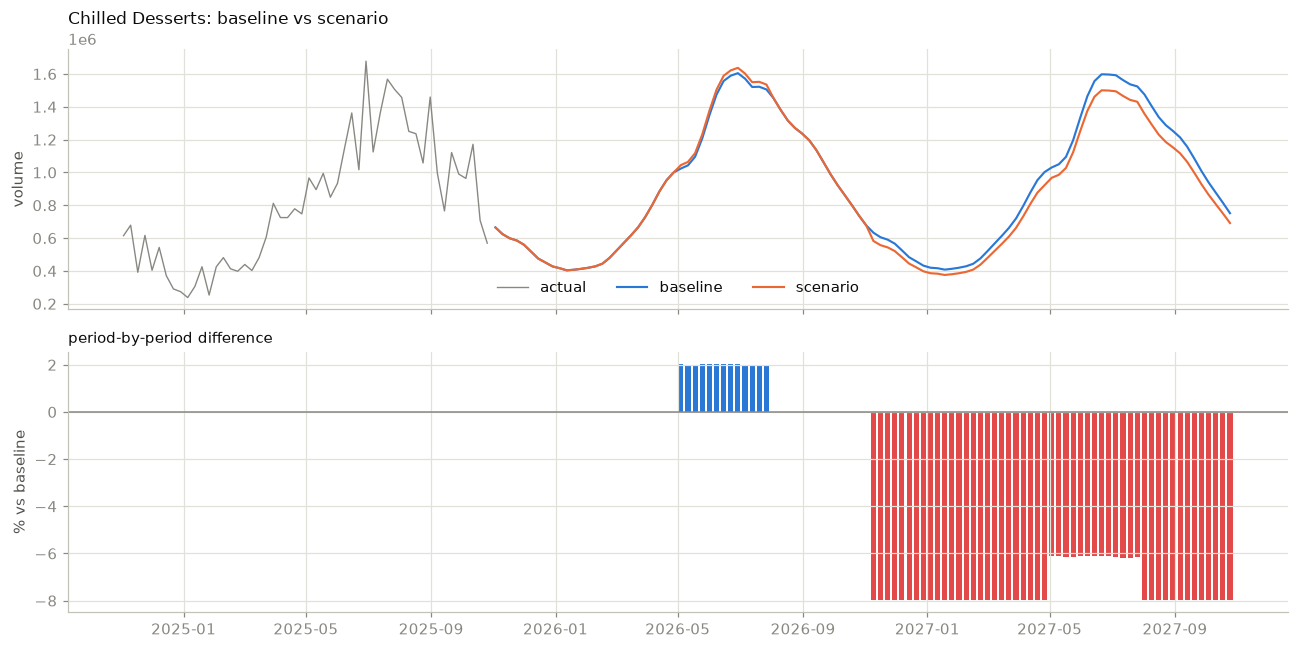

In [24]:
print("What changed in the plan:")
display(r["changes"].round(2))
print("\nWhere the volume difference comes from:")
display(r["waterfall"].round(1))

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
p = r["paths"]
h = panel[panel.category == cat].tail(int(PERIODS_PER_YEAR))
axes[0].plot(h["date"], h["volume"], color=INK_MUTED, lw=0.9, label="actual")
axes[0].plot(p["date"], p["baseline"], color=SERIES[0], lw=1.4, label="baseline")
axes[0].plot(p["date"], p["scenario"], color=SERIES[1], lw=1.4, label="scenario")
axes[0].set_ylabel("volume"); axes[0].legend(frameon=False, ncol=3)
axes[0].set_title(f"{cat}: baseline vs scenario", loc="left", fontsize=11)

pct = 100 * p["delta"] / p["baseline"]
axes[1].bar(p["date"], pct, width=5, color=[POS if v > 0 else NEG for v in pct])
axes[1].axhline(0, color=INK_MUTED, lw=1)
axes[1].set_ylabel("% vs baseline")
axes[1].set_title("period-by-period difference", loc="left", fontsize=10)
plt.tight_layout(); plt.show()

The shape of the difference is the part worth looking at. If you raised media in
selected periods, the uplift should appear in those periods and **decay for a few
periods afterwards** rather than stopping dead — that is the validated carryover.
A step change should start exactly when you made it start. If it does not, check
your edit before you check the model.

## §11. Export

Everything a downstream tool or a colleague needs. The baseline file is the one to
send to a planner: it is the download half of the scenario loop.

In [25]:
from pathlib import Path

OUT_DIR = Path("planner_output")
OUT_DIR.mkdir(exist_ok=True)

baseline.to_csv(OUT_DIR / "baseline_drivers.csv", index=False)
driver_fc.to_csv(OUT_DIR / "driver_forecast.csv", index=False)
summary.to_csv(OUT_DIR / "model_summary.csv")

impacts_all = pd.concat([models[c].impacts().assign(category=c) for c in CATEGORIES],
                        ignore_index=True)
impacts_all.to_csv(OUT_DIR / "driver_impacts.csv", index=False)

pd.concat([stability[c].assign(category=c) for c in CATEGORIES]).to_csv(
    OUT_DIR / "coefficient_stability.csv")

selection_rows = [{"category": c, "selected": ", ".join(models[c].drivers),
                   "dropped": ", ".join(models[c].selection["dropped"]),
                   "dropped_wrong_sign": ", ".join(models[c].selection["dropped_wrong_sign"]),
                   **models[c].selection["config"]} for c in CATEGORIES]
pd.DataFrame(selection_rows).to_csv(OUT_DIR / "feature_selection.csv", index=False)

# Per-category driver files, ready to hand out for editing.
for c in CATEGORIES:
    safe = "".join(ch if ch.isalnum() else "_" for ch in c).lower()
    baseline[baseline.category == c].to_csv(OUT_DIR / f"plan_{safe}.csv", index=False)

print(f"Wrote to {OUT_DIR.resolve()}:")
for f in sorted(OUT_DIR.iterdir()):
    print(f"  {f.name:<34} {f.stat().st_size / 1024:7.1f} KB")

Wrote to /Users/mshinde/Desktop/Personal/scenario_tool/experiments/weekly_planner/planner_output:
  baseline_drivers.csv                 173.7 KB
  coefficient_stability.csv              3.5 KB
  driver_forecast.csv                   50.9 KB
  driver_impacts.csv                     2.3 KB
  feature_selection.csv                  0.5 KB
  model_summary.csv                      0.2 KB
  plan_chilled_desserts.csv             60.8 KB
  plan_home_care.csv                    53.6 KB
  plan_hot_beverages.csv                59.7 KB


## Checklist before anyone plans on this

1. **§2 clean?** Errors fixed, warnings understood. A near-duplicate driver pair
   left in place will produce two unstable coefficients and no warning later.
2. **§1 priors set by a human?** The generated spec guesses `sign` and
   `controllable` from column names. It will get some wrong, and those two fields
   change which drivers survive selection.
3. **Test bias small?** (§7) A persistent bias means something is moving your
   volume that the model has no column for. Find it before you plan around the
   model.
4. **Stable coefficients?** (§8b) Anything marked `UNSTABLE` or `shaky` should not
   be used to justify a decision, whatever the holdout says.
5. **Contradictions resolved?** (§8c) A driver dropped for contradicting your prior
   is a disagreement between you and the data. One of you is wrong; find out which
   before shipping.
6. **Scenario shape sensible?** (§10) Changes should start when you started them
   and decay the way carryover implies.

### Common adjustments

| you want | change |
|---|---|
| monthly instead of weekly | nothing — frequency is detected. Set `FORECAST_PERIODS=24`, `TEST_PERIODS=12` |
| fewer drivers retained | raise `SELECTION_TOLERANCE` (e.g. `0.01`) |
| keep a lever the search drops | make sure `controllable=True`; lower `MATERIALITY_PCT` |
| more/less seasonal wiggle | widen or narrow `GRID["fourier_k"]` |
| longer media carryover | add higher values to `GRID["adstock_decay"]` |
| a single category | put a constant in the category column |
| no sign priors | set every `sign` to `0` — the check disables itself |